In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
file_path = "meme_ocr_dataset_final.xlsx"
df = pd.read_excel(file_path)

In [3]:
# Preview
print("Dataset Preview:")
print(df.head())

# Basic info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Preview:
                image                                           ocr-text  \
0  /meme_images/1.png  Bride and groom | =iends & Relatives | Kds | S...   
1  /meme_images/2.png  told you donit mess | with Smriti Mandana. | {...   
2  /meme_images/3.png  ro | 0/45 (2.4) | 4 (10) | 2 (5) | PAKISTAN | ...   
3  /meme_images/4.png  Anything Wrong Happen | In The World | World* ...   
4  /meme_images/5.png  Aap ke team | mein kitne SC, ST, | OBC hai | 2...   

   image-label  text-label  image-text-label  
0          0.0         0.0               0.0  
1          1.0         0.0               1.0  
2          0.0         1.0               1.0  
3          1.0         1.0               1.0  
4          1.0         0.0               1.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4584 entries, 0 to 4583
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   image             4584 n

In [4]:
# -------------------------------
# LABEL COUNTS
# -------------------------------

image_counts = df['image-label'].value_counts()
text_counts = df['text-label'].value_counts()
overall_counts = df['image-text-label'].value_counts()

print("\nImage Label Counts:\n", image_counts)
print("\nText Label Counts:\n", text_counts)
print("\nOverall Meme Label Counts:\n", overall_counts)


Image Label Counts:
 image-label
0.0    3240
1.0    1343
Name: count, dtype: int64

Text Label Counts:
 text-label
0.0    2450
1.0    2133
Name: count, dtype: int64

Overall Meme Label Counts:
 image-text-label
0.0    2308
1.0    2275
Name: count, dtype: int64


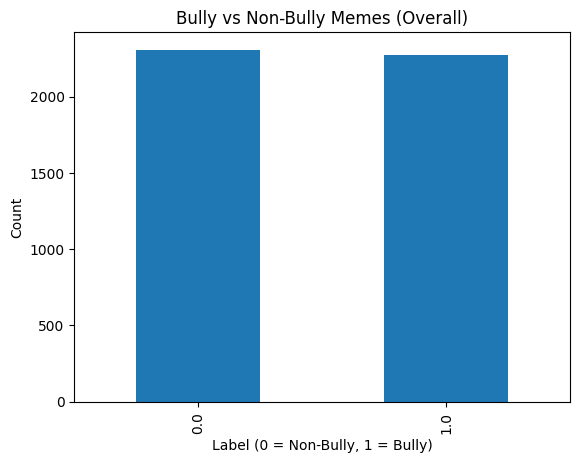

In [5]:

# -------------------------------
# GRAPH 1: Overall Bully vs Non-Bully
# -------------------------------
plt.figure()
overall_counts.plot(kind='bar')
plt.title("Bully vs Non-Bully Memes (Overall)")
plt.xlabel("Label (0 = Non-Bully, 1 = Bully)")
plt.ylabel("Count")
plt.show()

In [6]:

# -------------------------------
# GRAPH 2: Image vs Text Bullying
# -------------------------------
plt.figure()
comparison_df = pd.DataFrame({
    'Image Bully': image_counts,
    'Text Bully': text_counts
}).fillna(0)

<Figure size 640x480 with 0 Axes>

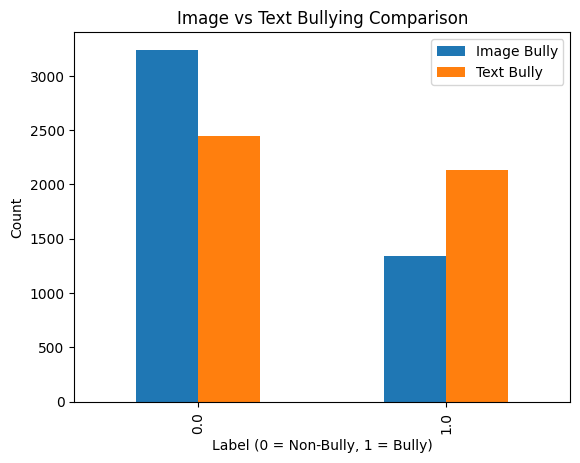

In [7]:
comparison_df.plot(kind='bar')
plt.title("Image vs Text Bullying Comparison")
plt.xlabel("Label (0 = Non-Bully, 1 = Bully)")
plt.ylabel("Count")
plt.show()

In [8]:
# -------------------------------
# CROSS ANALYSIS
# -------------------------------
cross_tab = pd.crosstab(df['image-label'], df['text-label'])

print("\nCross Analysis (Image vs Text):")
print(cross_tab)



Cross Analysis (Image vs Text):
text-label    0.0   1.0
image-label            
0.0          2240  1000
1.0           210  1133


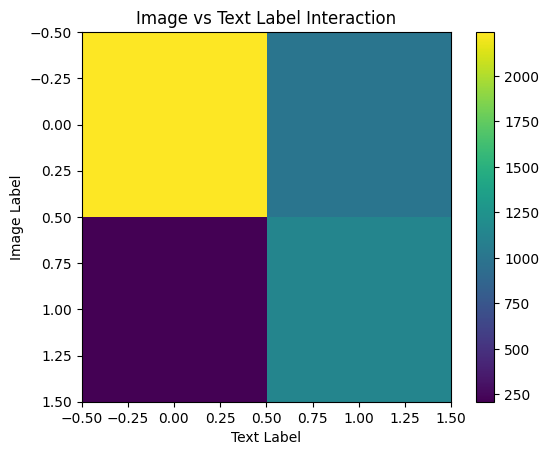

In [9]:
# -------------------------------
# GRAPH 3: Cross Analysis Heatmap-like (simple)
# -------------------------------
plt.figure()
plt.imshow(cross_tab)
plt.title("Image vs Text Label Interaction")
plt.xlabel("Text Label")
plt.ylabel("Image Label")
plt.colorbar()
plt.show()

In [10]:
# -------------------------------
# PERCENTAGE ANALYSIS
# -------------------------------
total = len(df)

print("\n--- Percentage Analysis ---")
print(f"Bully Memes (Overall): {(overall_counts.get(1,0)/total)*100:.2f}%")
print(f"Non-Bully Memes (Overall): {(overall_counts.get(0,0)/total)*100:.2f}%")

print(f"Image Bully %: {(image_counts.get(1,0)/total)*100:.2f}%")
print(f"Text Bully %: {(text_counts.get(1,0)/total)*100:.2f}%")

# -------------------------------
# INSIGHT: Mismatch Cases
# -------------------------------
mismatch = df[(df['image-label'] != df['text-label'])]

print("\nMismatch Cases (Image vs Text Disagree):")
print(mismatch[['image', 'ocr-text', 'image-label', 'text-label']].head())

print(f"\nTotal Mismatch Cases: {len(mismatch)}")


--- Percentage Analysis ---
Bully Memes (Overall): 49.63%
Non-Bully Memes (Overall): 50.35%
Image Bully %: 29.30%
Text Bully %: 46.53%

Mismatch Cases (Image vs Text Disagree):
                image                                           ocr-text  \
1  /meme_images/2.png  told you donit mess | with Smriti Mandana. | {...   
2  /meme_images/3.png  ro | 0/45 (2.4) | 4 (10) | 2 (5) | PAKISTAN | ...   
4  /meme_images/5.png  Aap ke team | mein kitne SC, ST, | OBC hai | 2...   
5  /meme_images/6.png                    Peak Days Of Collaborations | N   
6  /meme_images/7.png  Messi in Delhi | Messi in Mumbai | Messi in | ...   

   image-label  text-label  
1          1.0         0.0  
2          0.0         1.0  
4          1.0         0.0  
5          0.0         1.0  
6          0.0         1.0  

Total Mismatch Cases: 1211


In [11]:
from imblearn.over_sampling import SMOTE

# Example: using only labels won't work — you need features
# Suppose X = features, y = labels

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

NameError: name 'X' is not defined

In [14]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [1]:
import pandas as pd

# Load Excel file
df = pd.read_excel("meme_ocr_dataset (1).xlsx")

# Save as CSV
df.to_csv("meme_ocr_dataset.csv", index=False)

print("Converted successfully!")

Converted successfully!


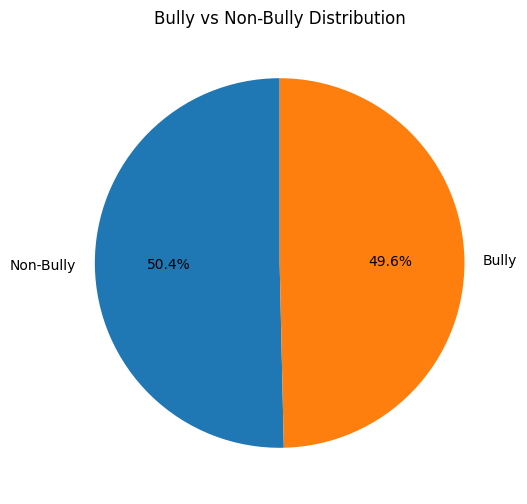

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "meme_ocr_dataset_final.xlsx"
df = pd.read_excel(file_path)

# Count labels
counts = df['image-text-label'].value_counts()

# Rename labels
labels = ['Non-Bully', 'Bully']

# Draw pie chart
plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Bully vs Non-Bully Distribution")

plt.show()